# Question 2 — Transfer Learning: Freeze vs. Fine-Tune
## Use a pretrained model such as ResNet18, ResNet50, VGG16, or another standard pretrained CNN.

Use an image-classification dataset with at least two classes.

Experiment A — Feature Extraction
- Load the pretrained network. 
- Freeze the convolutional/base layers. 
- Replace the final classification layer. 
- Train only the new classifier. 

Experiment B — Fine-Tuning
- Start with the pretrained network. 
- Unfreeze at least the last convolutional block. 
- Train the unfrozen layers and classifier.  

For both experiments:
- Report the number of trainable parameters.
- Train for the same number of epochs.
- Record training time.
- Report test or validation accuracy.
- Plot training loss.
- Compare the two approaches in a table:

| Method | Trainable Parameters | Training Time | Accuracy |
| :--- | :--- | :--- | :--- |
| Frozen Feature Extractor | | | |
| Fine-Tuned Network | | | |
	
g. In 5–8 sentences, discuss the results. Explain why freezing layers and fine-tuning layers may produce different training times and performance.


# Experiment A- Freezing the base layer and replacing the classifier

In [1]:
import time
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

from torchvision import datasets
from torchvision.models import resnet18, ResNet18_Weights
from torch.utils.data import DataLoader, Subset

In [10]:
# Device configuration
torch.manual_seed(42)
EPOCHS = 20
BATCH_SIZE = 32

device = torch.device(
    "cuda" if torch.cuda.is_available()
    else "mps" if torch.backends.mps.is_available()
    else "cpu"
)
print("Device:", device)


Device: mps


In [5]:
# Initialize the CIFAR-10 dataset and apply the transformations
weights = ResNet18_Weights.DEFAULT
transform = weights.transforms()

train_data = datasets.CIFAR10(
    "./data", train=True, download=True, transform=transform
)
test_data = datasets.CIFAR10(
    "./data", train=False, download=True, transform=transform
)

In [6]:
# Select the same 500 images per class in both experiments.
generator = torch.Generator().manual_seed(42)
targets = torch.tensor(train_data.targets)
selected = []

for class_id in range(10):
    indices = torch.where(targets == class_id)[0]
    order = torch.randperm(len(indices), generator=generator)
    selected.extend(indices[order[:500]].tolist())

train_data = Subset(train_data, selected)

train_loader = DataLoader(
    train_data,
    batch_size=BATCH_SIZE,
    shuffle=True,
    generator=torch.Generator().manual_seed(42),
    num_workers=0
)
test_loader = DataLoader(
    test_data, batch_size=BATCH_SIZE, shuffle=False, num_workers=0
)

In [7]:
# Load pretrained model and freeze all existing layers.
model = resnet18(weights=weights)

for parameter in model.parameters():
    parameter.requires_grad = False

# The new classifier is trainable by default.
model.fc = nn.Linear(model.fc.in_features, 10)
model = model.to(device)

trainable = sum(
    p.numel() for p in model.parameters() if p.requires_grad
)
print(f"Trainable parameters: {trainable:,}")


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /Users/aryamanshrestha/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100.0%


Trainable parameters: 5,130


In [8]:
# Define the loss function and optimizer

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.fc.parameters(), lr=0.001)


def synchronize():
    if device.type == "cuda":
        torch.cuda.synchronize()
    elif device.type == "mps":
        torch.mps.synchronize()


In [11]:
# Train only the classifier.
loss_history = []
training_time = 0.0

for epoch in range(EPOCHS):
    # Keep the frozen base, including BatchNorm statistics, fixed.
    model.eval()
    model.fc.train()

    total_loss = 0.0
    synchronize()
    start = time.perf_counter()

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad(set_to_none=True)
        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        total_loss += loss.item() * images.size(0)

    synchronize()
    training_time += time.perf_counter() - start

    average_loss = total_loss / len(train_data)
    loss_history.append(average_loss)
    print(f"Epoch {epoch + 1}/{EPOCHS}: loss = {average_loss:.4f}")


Epoch 1/20: loss = 0.3796
Epoch 2/20: loss = 0.3573
Epoch 3/20: loss = 0.3416
Epoch 4/20: loss = 0.3292
Epoch 5/20: loss = 0.3105
Epoch 6/20: loss = 0.3025
Epoch 7/20: loss = 0.2914
Epoch 8/20: loss = 0.2841
Epoch 9/20: loss = 0.2736
Epoch 10/20: loss = 0.2668
Epoch 11/20: loss = 0.2557
Epoch 12/20: loss = 0.2541
Epoch 13/20: loss = 0.2440
Epoch 14/20: loss = 0.2373
Epoch 15/20: loss = 0.2307
Epoch 16/20: loss = 0.2258
Epoch 17/20: loss = 0.2242
Epoch 18/20: loss = 0.2149
Epoch 19/20: loss = 0.2113
Epoch 20/20: loss = 0.2074


In [13]:
# Evaluate the model on the test set and compute accuracy
model.eval()
correct = 0
total = 0

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        predictions = model(images).argmax(dim=1)

        correct += (predictions == labels).sum().item()
        total += labels.size(0)

accuracy = 100 * correct / total



Experiment A — Frozen Feature Extractor
Trainable parameters: 5,130
Training time: 201.46 seconds
Test accuracy: 83.16%


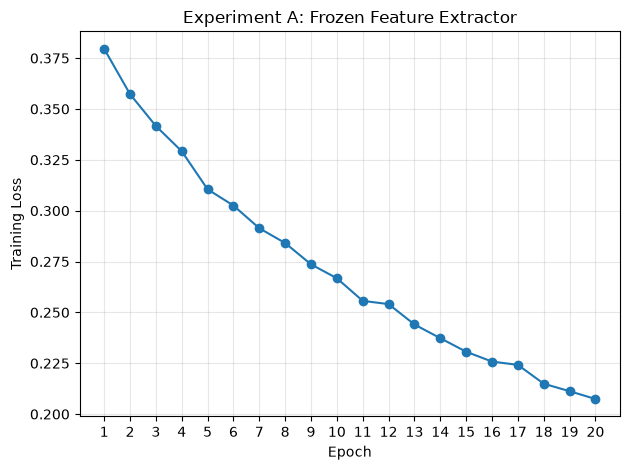

In [14]:
print("\nExperiment A — Frozen Feature Extractor")
print(f"Trainable parameters: {trainable:,}")
print(f"Training time: {training_time:.2f} seconds")
print(f"Test accuracy: {accuracy:.2f}%")

plt.plot(range(1, EPOCHS + 1), loss_history, "o-")
plt.title("Experiment A: Frozen Feature Extractor")
plt.xlabel("Epoch")
plt.ylabel("Training Loss")
plt.xticks(range(1, EPOCHS + 1))
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()